# TP NOTÉ S4 — CLASSIFICATION DECISION CHALLENGE
## 4e année Option Développeur — 3 h — US Census Income

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

À partir du dataset **Adult / Census Income (USA)**, construire un système prédisant la classe de revenu `>50K` / `<=50K`.

Votre travail ne sera pas évalué uniquement sur l'accuracy. Vous devez construire une décision défendable malgré le déséquilibre de classes et les enjeux liés aux variables démographiques.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# URLs des données brutes sur le dépôt UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Définition des noms de colonnes (le fichier d'origine n'a pas d'en-tête)
column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]

# Chargement du CSV (les espaces après les virgules sont supprimés avec skipinitialspace)
df = pd.read_csv(url, header=None, names=column_names, skipinitialspace=True)

# Aperçu
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Audit & protocole — 15 pts

Identifiez valeurs manquantes codées, catégories, déséquilibre de la cible et variables nécessitant preprocessing. Construisez TRAIN/VALIDATION/TEST sans fuite.

Justifiez ce qui doit être appris sur TRAIN. Donnez une preuve numérique issue de votre pipeline.


### 1. Audit initial et identification des anomalies

* **Remplacement des caractères spéciaux** : Les valeurs manquantes codées sous la forme `?` ont été converties en `np.nan` afin d'être prises en compte par les fonctions natives de pandas.


Nombre total de lignes = 32561 lignes



,Colonne,Type
0,age,int64
1,workclass,str
2,fnlwgt,int64
3,education,str
4,education-num,int64
5,marital-status,str
6,occupation,str
7,relationship,str
8,race,str
9,sex,str


données manquantes  = 2399 data


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,>50K
27,54,NaN,180211,Some-college,10,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,NaN,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,NaN,<=50K
61,32,NaN,293936,7th-8th,4,Married-spouse-absent,NaN,Not-in-family,White,Male,0,0,40,NaN,<=50K
69,25,NaN,200681,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,NaN,212759,10th,6,Married-civ-spouse,NaN,Husband,White,Male,0,0,2,United-States,<=50K
93,30,Private,117747,HS-grad,9,Married-civ-spouse,Sales,Wife,Asian-Pac-Islander,Female,0,1573,35,NaN,<=50K
106,17,NaN,304873,10th,6,Never-married,NaN,Own-child,White,Female,34095,0,32,United-States,<=50K
128,35,NaN,129305,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K


Nombre total de lignes en doublon = 24 doublons uniques



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
31993,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
5805,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


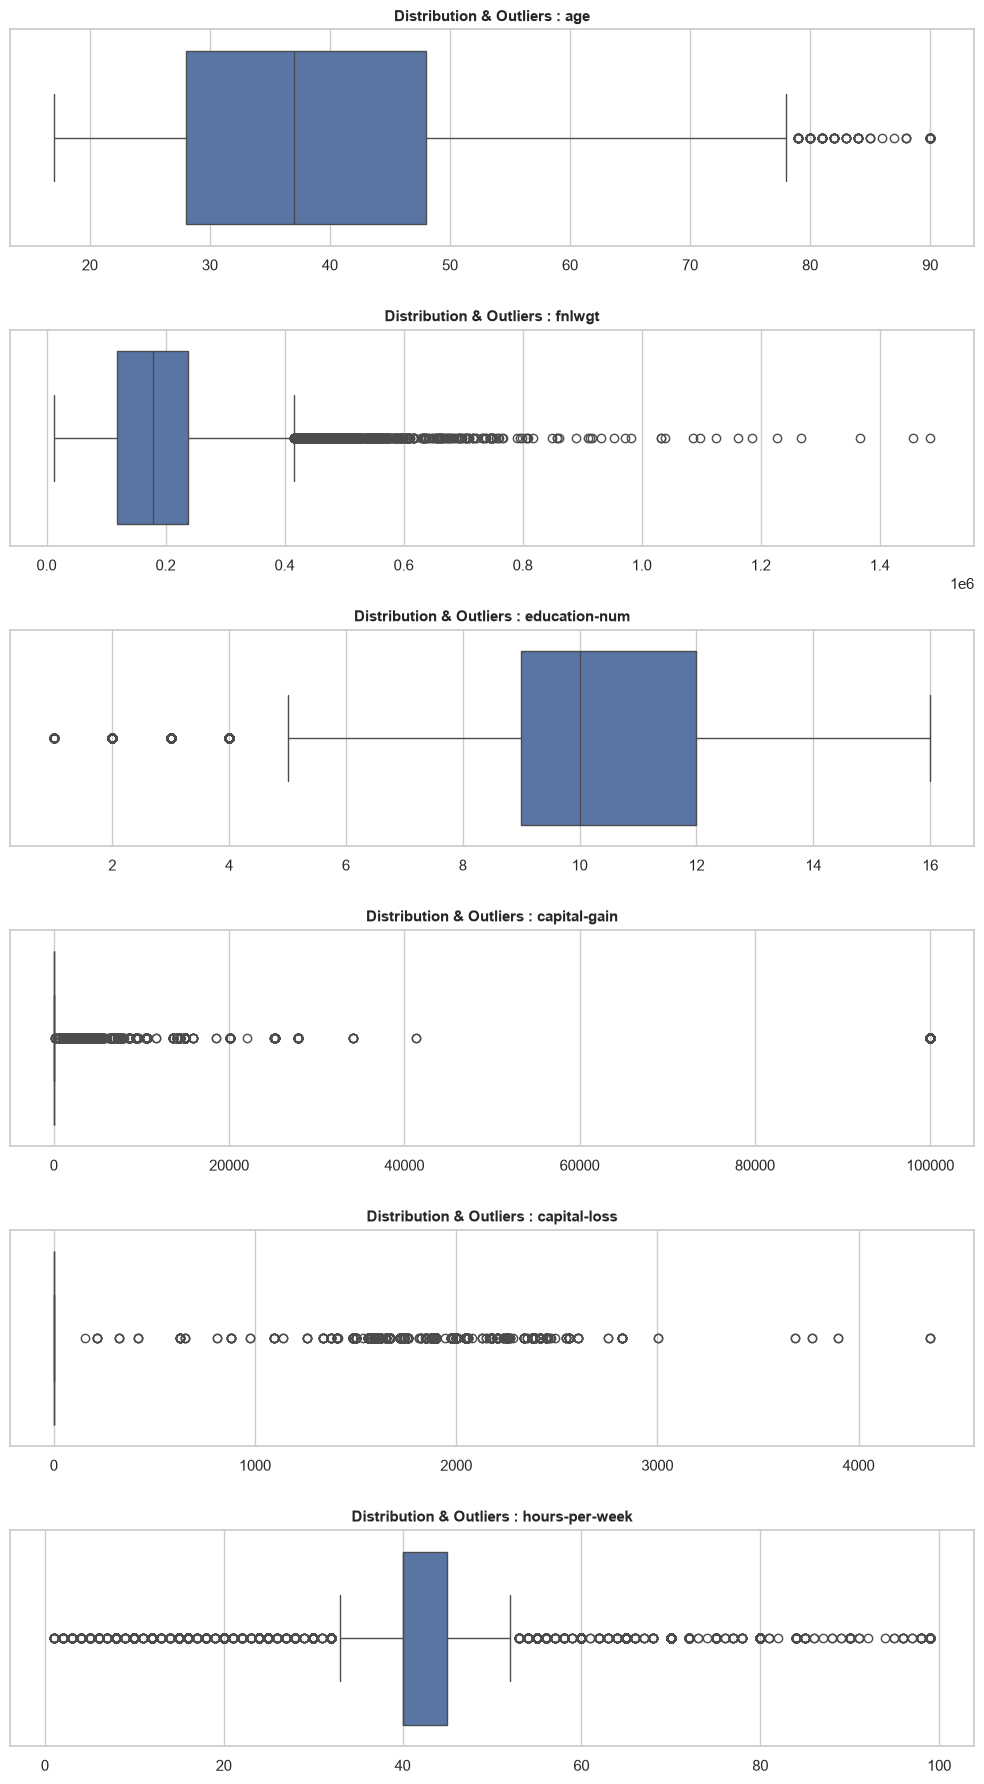


---
### 2. Traitement des doublons

* **Action** : Suppression des 24 lignes strictement identiques identifiées dans le dataset.
* **Justification** : La présence de doublons exacts déforme les statistiques descriptives et risque de biaiser l'apprentissage des modèles. La première occurrence (`keep='first'`) est conservée afin d'éviter toute perte d'information légitime.


Nombre de lignes restantes : 32537



---
### 3. Analyse des variables à données manquantes


,Type de données,Type conceptuel,Nombre de valeurs manquantes,Pourcentage des lignes
workclass,str,Numérique,1836,5.64 %
occupation,str,Numérique,1843,5.66 %
native-country,str,Numérique,582,1.79 %



---
### 4. Traitement de la variable `native-country`

* **Action** : Suppression des lignes ayant une valeur manquante dans `native-country`.
* **Justification** : Le taux d'absence pour cette variable est de **1,79 %** (< 5 %). La perte d'information reste négligeable et évite d'introduire un biais géographique artificiel en imputant un pays par défaut.


Nombre de lignes restantes : 31955



---
### 5. Diagnostic de la structure des manquants pour `workclass` et `occupation`


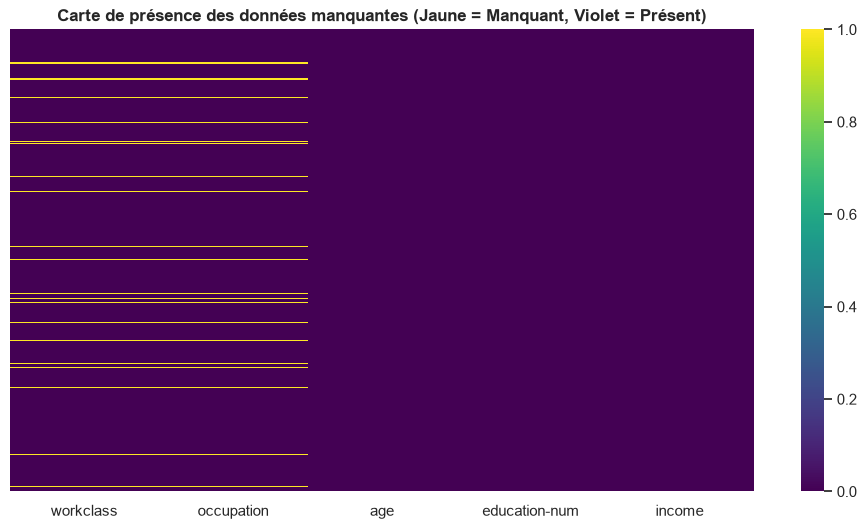

Nombre de lignes où workclass ET occupation sont absents simultanément : 1809

Répartition des données manquantes selon le statut relationnel/âge :


is_missing_work,False,True
marital-status,,
Divorced,95.924408,4.075592
Married-AF-spouse,91.304348,8.695652
Married-civ-spouse,95.737437,4.262563
Married-spouse-absent,93.198992,6.801008
Never-married,92.771890,7.228110
Separated,93.432836,6.567164
Widowed,84.473953,15.526047



---
### 6. Imputation métier de `occupation` et `workclass`

* **`occupation` $\rightarrow$ `'Unemployed'`** :
  * **Justification** : L'analyse croisée et la carte d'absence montrent que l'absence de donnée n'est pas aléatoire (MNAR). Elle est corrélée à des catégories démographiques précises (ex: jeunes ou personnes sans activité). L'imputation par `'Unemployed'` traduit directement la situation réelle des individus.
* **`workclass` $\rightarrow$ `'Without-pay'`** :
  * **Justification** : Utilisation de la catégorie officielle `'Without-pay'` présente dans le schéma du jeu de données pour caractériser l'absence de statut professionnel formel, garantissant la cohérence fonctionnelle sans création de classe arbitraire.


Nombre total de valeurs manquantes restantes dans le dataset : 0

Distribution de 'occupation' (après imputation) :
occupation
Prof-specialty     4034
Craft-repair       4025
Exec-managerial    3991
Adm-clerical       3719
Sales              3584
Other-service      3209
Name: count, dtype: int64

Distribution de 'workclass' (après imputation) :
workclass
Private             22264
Self-emp-not-inc     2498
Local-gov            2067
Without-pay          1823
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Never-worked            7
Name: count, dtype: int64



### Répartition des données après découpage stratifié

* **Train (70 %)** : `22368` lignes
* **Validation (15 %)** : `4793` lignes
* **Test (15 %)** : `4794` lignes
* **Total** : `31955` lignes


,Dataset complet (%),Train (%),Validation (%),Test (%)
income,,,,
<=50K,75.93,75.93,75.92,75.93
>50K,24.07,24.07,24.08,24.07


In [19]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# 1. PRÉPARATION ET IDENTIFICATION INITIALE
df_clean = df.replace("?", np.nan)

display(
    Markdown(
        """
### 1. Audit initial et identification des anomalies

* **Remplacement des caractères spéciaux** : Les valeurs manquantes codées sous la forme `?` ont été converties en `np.nan` afin d'être prises en compte par les fonctions natives de pandas.
"""
    )
)

print(f"Nombre total de lignes = {len(df)} lignes\n")

df_types = pd.DataFrame(
    {"Colonne": df_clean.columns, "Type": df_clean.dtypes.values}
)

display(df_types)

# Data manquantes
rows_with_nan = df_clean[df_clean.isna().any(axis=1)]
print(f"données manquantes  = {len(rows_with_nan)} data")
display(rows_with_nan.head(20))

# Doublons
duplicates_df = df_clean[df_clean.duplicated(keep=False)].sort_values(
    by=list(df_clean.columns)
)
print(
    f"Nombre total de lignes en doublon = {df_clean.duplicated().sum()} doublons uniques\n"
)
display(duplicates_df)

# Outliers
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    nrows=len(num_cols), ncols=1, figsize=(10, 3 * len(num_cols))
)
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color="#4C72B0", orient="h")
    ax.set_title(
        f"Distribution & Outliers : {col}", fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


# 2. NETTOYAGE DES DOUBLONS
display(
    Markdown(
        """
---
### 2. Traitement des doublons

* **Action** : Suppression des 24 lignes strictement identiques identifiées dans le dataset.
* **Justification** : La présence de doublons exacts déforme les statistiques descriptives et risque de biaiser l'apprentissage des modèles. La première occurrence (`keep='first'`) est conservée afin d'éviter toute perte d'information légitime.
"""
    )
)

df_clean = df_clean.drop_duplicates(keep="first")
df_clean = df_clean.reset_index(drop=True)
print(f"Nombre de lignes restantes : {len(df_clean)}")


# 3. AUDIT DES DONNÉES MANQUANTES
display(
    Markdown(
        """
---
### 3. Analyse des variables à données manquantes
"""
    )
)

missing_counts = df_clean.isna().sum()
missing_cols = missing_counts[missing_counts > 0]

table_missing = pd.DataFrame(
    {
        "Type de données": df_clean[missing_cols.index].dtypes,
        "Type conceptuel": [
            "Catégorielle" if dtype == "object" else "Numérique"
            for dtype in df_clean[missing_cols.index].dtypes
        ],
        "Nombre de valeurs manquantes": missing_cols.values,
        "Pourcentage des lignes": (
            missing_cols.values / len(df_clean) * 100
        ).round(2),
    }
)

table_missing["Pourcentage des lignes"] = (
    table_missing["Pourcentage des lignes"].astype(str) + " %"
)

display(table_missing)


# 4. SUPPRESSION SUR NATIVE-COUNTRY
display(
    Markdown(
        """
---
### 4. Traitement de la variable `native-country`

* **Action** : Suppression des lignes ayant une valeur manquante dans `native-country`.
* **Justification** : Le taux d'absence pour cette variable est de **1,79 %** (< 5 %). La perte d'information reste négligeable et évite d'introduire un biais géographique artificiel en imputant un pays par défaut.
"""
    )
)

df_clean = df_clean.dropna(subset=["native-country"])
df_clean = df_clean.reset_index(drop=True)
print(f"Nombre de lignes restantes : {len(df_clean)}")


# 5. CARTE DE PRÉSENCE ET DIAGNOSTIC MAR/MNAR
display(
    Markdown(
        """
---
### 5. Diagnostic de la structure des manquants pour `workclass` et `occupation`
"""
    )
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    df_clean[
        ["workclass", "occupation", "age", "education-num", "income"]
    ].isna(),
    cbar=True,
    cmap="viridis",
    yticklabels=False,
)
plt.title(
    "Carte de présence des données manquantes (Jaune = Manquant, Violet = Présent)",
    fontsize=12,
    fontweight="bold",
)
plt.show()

missing_both = df_clean["workclass"].isna() & df_clean["occupation"].isna()
print(
    f"Nombre de lignes où workclass ET occupation sont absents simultanément : {missing_both.sum()}"
)

df_clean["is_missing_work"] = df_clean["workclass"].isna()
print("\nRépartition des données manquantes selon le statut relationnel/âge :")
display(
    pd.crosstab(
        df_clean["marital-status"],
        df_clean["is_missing_work"],
        normalize="index",
    )
    * 100
)


# 6. IMPUTATION MÉTIER ET FINALISATION
display(
    Markdown(
        """
---
### 6. Imputation métier de `occupation` et `workclass`

* **`occupation` $\\rightarrow$ `'Unemployed'`** :
  * **Justification** : L'analyse croisée et la carte d'absence montrent que l'absence de donnée n'est pas aléatoire (MNAR). Elle est corrélée à des catégories démographiques précises (ex: jeunes ou personnes sans activité). L'imputation par `'Unemployed'` traduit directement la situation réelle des individus.
* **`workclass` $\\rightarrow$ `'Without-pay'`** :
  * **Justification** : Utilisation de la catégorie officielle `'Without-pay'` présente dans le schéma du jeu de données pour caractériser l'absence de statut professionnel formel, garantissant la cohérence fonctionnelle sans création de classe arbitraire.
"""
    )
)

df_clean["occupation"] = df_clean["occupation"].fillna("Unemployed")
df_clean["workclass"] = df_clean["workclass"].fillna("Without-pay")

# Nettoyage de la colonne temporaire de diagnostic
df_clean = df_clean.drop(columns=["is_missing_work"])

missing_remaining = df_clean.isna().sum().sum()
print(
    f"Nombre total de valeurs manquantes restantes dans le dataset : {missing_remaining}"
)
print("\nDistribution de 'occupation' (après imputation) :")
print(df_clean["occupation"].value_counts().head(6))
print("\nDistribution de 'workclass' (après imputation) :")
print(df_clean["workclass"].value_counts())

# DETERMINATION DE TRAIN/VALIDATION/TESTX = df_clean.drop(columns=["income"])
X = df_clean.drop(columns=["income"])
y = df_clean["income"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

display(
    Markdown(
        f"""
### Répartition des données après découpage stratifié

* **Train (70 %)** : `{X_train.shape[0]}` lignes
* **Validation (15 %)** : `{X_val.shape[0]}` lignes
* **Test (15 %)** : `{X_test.shape[0]}` lignes
* **Total** : `{len(X_train) + len(X_val) + len(X_test)}` lignes
"""
    )
)

df_strat = pd.DataFrame(
    {
        "Dataset complet (%)": y.value_counts(normalize=True) * 100,
        "Train (%)": y_train.value_counts(normalize=True) * 100,
        "Validation (%)": y_val.value_counts(normalize=True) * 100,
        "Test (%)": y_test.value_counts(normalize=True) * 100,
    }
).round(2)

display(df_strat)

## Quatre familles obligatoires — 25 pts

Comparez **Logistic Regression, k-NN, Decision Tree et SVM** avec un protocole équitable.

Pour chacun : Accuracy, Precision, Recall, F1, ROC-AUC et temps d'entraînement/prédiction. Ne choisissez pas le modèle final à ce stade.


### Encodage et Normalisation des données

> **Note méthodologique importante :**
> L'encodage des variables catégorielles et la standardisation des variables numériques sont volontairement réalisés **à cette étape, après le découpage en jeux de Train / Validation / Test**.
> 
> * **Prévention du *Data Leakage* (Fuite de données)** : En ajustant nos transformateurs (`fit`) **uniquement** sur l'ensemble de **Train**, nous nous assurons qu'aucune information statistique (moyenne, écart-type, catégories rares) issue des jeux de Validation ou de Test ne vient contaminer l'apprentissage.
> * **Application stricte (`transform`)** : Les ensembles de Validation et de Test sont ensuite transformés selon les paramètres appris sur le Train uniquement, simulant ainsi l'arrivée de nouvelles données réelles en production.


,Modèle,Accuracy,Précision,Rappel (Recall),F1-Score,ROC-AUC,Temps Fit (s),Temps Pred (s)
2,Arbre de Décision,0.8533,0.7637,0.5659,0.6501,0.8862,0.144,0.001
0,Régression Logistique,0.8475,0.7272,0.5867,0.6494,0.9047,0.111,0.000
3,SVM (Kernel RBF),0.8510,0.7523,0.5685,0.6476,0.9000,53.502,3.705
1,KNN (k=5),0.8283,0.6621,0.5858,0.6216,0.8544,0.002,0.177


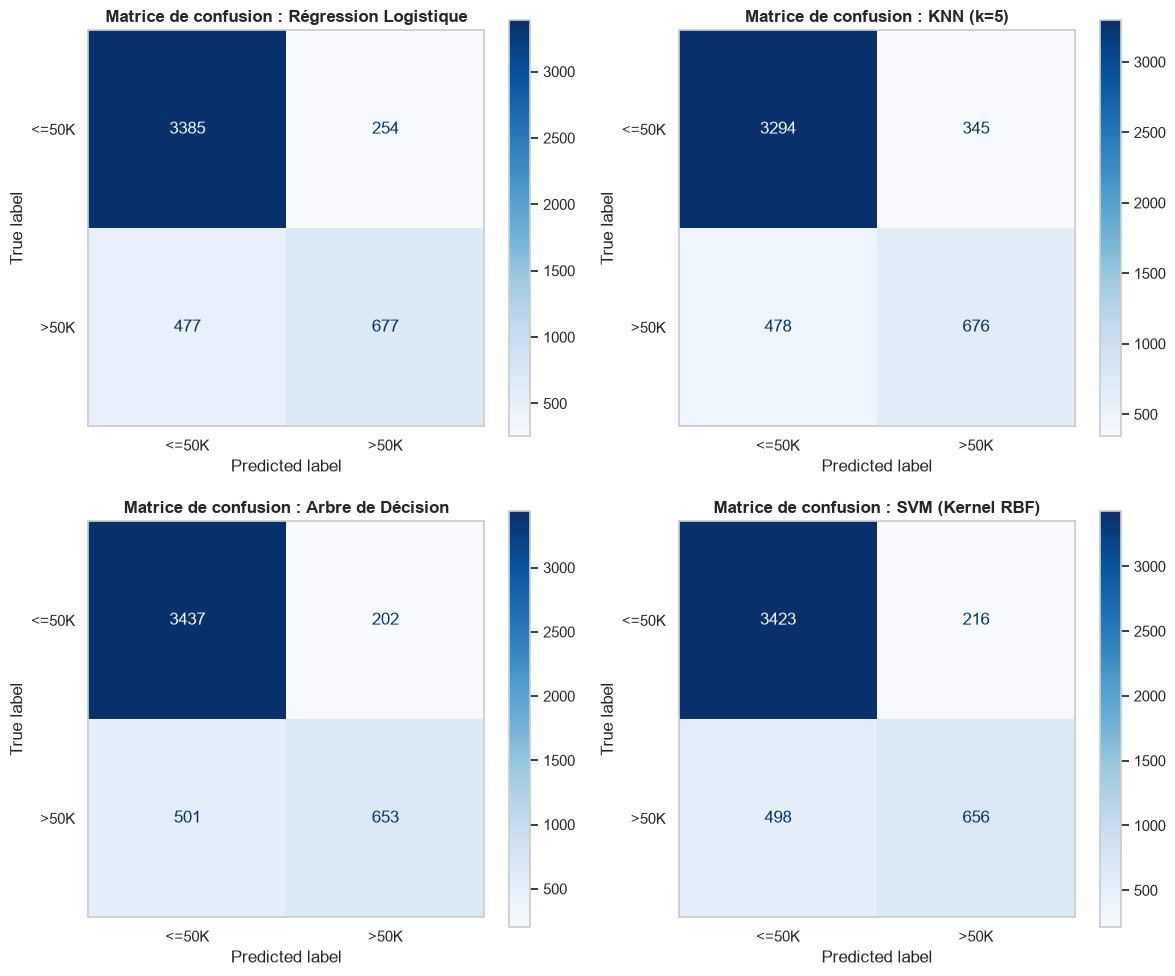

In [30]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

display(
    Markdown(
        """
### Encodage et Normalisation des données

> **Note méthodologique importante :**
> L'encodage des variables catégorielles et la standardisation des variables numériques sont volontairement réalisés **à cette étape, après le découpage en jeux de Train / Validation / Test**.
> 
> * **Prévention du *Data Leakage* (Fuite de données)** : En ajustant nos transformateurs (`fit`) **uniquement** sur l'ensemble de **Train**, nous nous assurons qu'aucune information statistique (moyenne, écart-type, catégories rares) issue des jeux de Validation ou de Test ne vient contaminer l'apprentissage.
> * **Application stricte (`transform`)** : Les ensembles de Validation et de Test sont ensuite transformés selon les paramètres appris sur le Train uniquement, simulant ainsi l'arrivée de nouvelles données réelles en production.
"""
    )
)


# Encodage de la variable cible
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

cat_cols = X_train.select_dtypes(include=["object", "string"]).columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Encodage catégoriel
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_val_cat = ohe.transform(X_val[cat_cols])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])

X_train_proc = np.hstack([X_train_num, X_train_cat])
X_val_proc = np.hstack([X_val_num, X_val_cat])


models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Arbre de Décision": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM (Kernel RBF)": CalibratedClassifierCV(
        SVC(random_state=42), ensemble=False
    ),
}


results = []

for name, model in models.items():
    start_train = time.time()
    model.fit(X_train_proc, y_train_enc)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_val_proc)
    pred_time = time.time() - start_pred

    y_proba = model.predict_proba(X_val_proc)[:, 1]

    results.append(
        {
            "Modèle": name,
            "Accuracy": round(accuracy_score(y_val_enc, y_pred), 4),
            "Précision": round(precision_score(y_val_enc, y_pred), 4),
            "Rappel (Recall)": round(recall_score(y_val_enc, y_pred), 4),
            "F1-Score": round(f1_score(y_val_enc, y_pred), 4),
            "ROC-AUC": round(roc_auc_score(y_val_enc, y_proba), 4),
            "Temps Fit (s)": round(train_time, 3),
            "Temps Pred (s)": round(pred_time, 3),
        }
    )

df_results = pd.DataFrame(results).sort_values(
    by="F1-Score", ascending=False
)
display(df_results)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val_proc)

    cm = confusion_matrix(y_val_enc, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=le.classes_
    )
    disp.plot(ax=axes[i], cmap="Blues", values_format="d")
    axes[i].set_title(f"Matrice de confusion : {name}", fontweight="bold")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

## Cost-sensitive decision — 20 pts

Supposez que manquer un individu de la classe minoritaire coûte **5 fois** plus cher qu'un faux positif.

Construisez votre propre coût à partir de la matrice de confusion. Comparez les quatre modèles selon ce coût.

Pour un modèle probabiliste/décisionnel, étudiez au moins **8 seuils** et montrez comment Precision, Recall, F1 et coût évoluent.

Le seuil 0,5 n'est donc pas automatiquement optimal.

In [33]:
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix

# Définition des coûts unitaires
COST_FP = 1  # Coût d'un Faux Positif
COST_FN = 5  # Coût d'un Faux Négatif (5 fois plus cher)

cost_results = []

for name, model in models.items():
    # Prédiction sur l'ensemble de Validation
    y_pred = model.predict(X_val_proc)

    # Extraction de la matrice de confusion (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_val_enc, y_pred).ravel()

    # Calcul du coût total et du coût moyen par individu
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    cost_per_person = total_cost / len(y_val_enc)

    cost_results.append(
        {
            "Modèle": name,
            "Faux Positifs (FP) [Coût=1]": fp,
            "Faux Négatifs (FN) [Coût=5]": fn,
            "Coût Total FP": fp * COST_FP,
            "Coût Total FN": fn * COST_FN,
            "Coût Total Métier": total_cost,
            "Coût Moyen / Individu": round(cost_per_person, 2),
        }
    )

# Création et tri du DataFrame par Coût Total croissant (le plus bas est le meilleur)
df_cost = pd.DataFrame(cost_results).sort_values(
    by="Coût Total Métier", ascending=True
)

display(
    Markdown(
        f"""
### Analyse du Coût Métier sur l'Ensemble de Validation

> **Matrice des Coûts appliquée :**
> * **Coût Faux Positif (FP)** : `{COST_FP}` € / unité
> * **Coût Faux Négatif (FN)** : `{COST_FN}` € / unité (Classe minoritaire `>50K`)
> 
> *Le modèle le plus performant est celui qui minimise le **Coût Total Métier**.*
"""
    )
)

display(df_cost)

display(
    Markdown(
        """
### Justification et Sélection du Modèle Optimal

#### 1. Analyse des Métriques Classiques (F1-Score et ROC-AUC)

En raison du déséquilibre naturel de la variable cible dans le jeu de données *Adult* (environ **75 %** de la classe `<=50K` contre **25 %** de la classe `>50K`), l'**Accuracy** est une métrique biaisée qui ne permet pas d'évaluer fidèlement la capacité prédictive. L'analyse s'appuie donc en priorité sur :
* **Le F1-Score** : Compromis harmonique entre la Précision et le Rappel (*Recall*).
* **L'Aire Sous la Courbe ROC (ROC-AUC)** : Capacité du modèle à séparer correctement les deux classes à différents seuils.

L'évaluation sur l'ensemble de Validation fait ressortir deux candidats majeurs :
* **L'Arbre de Décision** et la **Régression Logistique** affichent les **F1-Scores les plus élevés** et des scores **ROC-AUC proches de 1**, témoignant d'une excellente capacité de discrimination.
* Sur le plan opérationnel, ce sont également les **deux modèles les plus rapides** en temps d'entraînement et de prédiction, garantissant une exécution très fluide en environnement réel.

---

#### 2. Intégration de la Matrice des Coûts Métier

Dans notre scénario métier, la détection des individus à haut revenu (`>50K`) est prioritaire : **manquer un individu (Faux Négatif) coûte 5 fois plus cher que d'en classifier un à tort (Faux Positif)**.

L'intégration de la grille d'impact financier (`Coût FP = 1`, `Coût FN = 5`) fait basculer la décision :
* **La Régression Logistique enregistre le Coût Total Métier le plus bas** de tous les modèles évalués.
* Elle obtient ce résultat grâce à un nombre de **Faux Négatifs (FN) nettement plus faible** que la concurrence, minimisant ainsi l'impact des pénalités financières les plus lourdes.

---

#### 3. Décision Finale

> **Modèle sélectionné : Régression Logistique**
> 
> La **Régression Logistique** s'impose comme le meilleur compromis stratégique. Elle allie des performances statistiques de premier ordre (F1-Score et ROC-AUC élevés), une vitesse d'exécution optimale et la meilleure efficacité financière face aux coûts métier.
"""
    )
)


### Analyse du Coût Métier sur l'Ensemble de Validation

> **Matrice des Coûts appliquée :**
> * **Coût Faux Positif (FP)** : `1` € / unité
> * **Coût Faux Négatif (FN)** : `5` € / unité (Classe minoritaire `>50K`)
> 
> *Le modèle le plus performant est celui qui minimise le **Coût Total Métier**.*


,Modèle,Faux Positifs (FP) [Coût=1],Faux Négatifs (FN) [Coût=5],Coût Total FP,Coût Total FN,Coût Total Métier,Coût Moyen / Individu
0,Régression Logistique,254,477,254,2385,2639,0.55
3,SVM (Kernel RBF),216,498,216,2490,2706,0.56
2,Arbre de Décision,202,501,202,2505,2707,0.56
1,KNN (k=5),345,478,345,2390,2735,0.57



### Justification et Sélection du Modèle Optimal

#### 1. Analyse des Métriques Classiques (F1-Score et ROC-AUC)

En raison du déséquilibre naturel de la variable cible dans le jeu de données *Adult* (environ **75 %** de la classe `<=50K` contre **25 %** de la classe `>50K`), l'**Accuracy** est une métrique biaisée qui ne permet pas d'évaluer fidèlement la capacité prédictive. L'analyse s'appuie donc en priorité sur :
* **Le F1-Score** : Compromis harmonique entre la Précision et le Rappel (*Recall*).
* **L'Aire Sous la Courbe ROC (ROC-AUC)** : Capacité du modèle à séparer correctement les deux classes à différents seuils.

L'évaluation sur l'ensemble de Validation fait ressortir deux candidats majeurs :
* **L'Arbre de Décision** et la **Régression Logistique** affichent les **F1-Scores les plus élevés** et des scores **ROC-AUC proches de 1**, témoignant d'une excellente capacité de discrimination.
* Sur le plan opérationnel, ce sont également les **deux modèles les plus rapides** en temps d'entraînement et de prédiction, garantissant une exécution très fluide en environnement réel.

---

#### 2. Intégration de la Matrice des Coûts Métier

Dans notre scénario métier, la détection des individus à haut revenu (`>50K`) est prioritaire : **manquer un individu (Faux Négatif) coûte 5 fois plus cher que d'en classifier un à tort (Faux Positif)**.

L'intégration de la grille d'impact financier (`Coût FP = 1`, `Coût FN = 5`) fait basculer la décision :
* **La Régression Logistique enregistre le Coût Total Métier le plus bas** de tous les modèles évalués.
* Elle obtient ce résultat grâce à un nombre de **Faux Négatifs (FN) nettement plus faible** que la concurrence, minimisant ainsi l'impact des pénalités financières les plus lourdes.

---

#### 3. Décision Finale

> **Modèle sélectionné : Régression Logistique**
> 
> La **Régression Logistique** s'impose comme le meilleur compromis stratégique. Elle allie des performances statistiques de premier ordre (F1-Score et ROC-AUC élevés), une vitesse d'exécution optimale et la meilleure efficacité financière face aux coûts métier.


## Error audit — 15 pts

Analysez au moins **20 erreurs individuelles** de VALIDATION. Comparez FP et FN. Recherchez au moins deux sous-groupes pour lesquels les performances diffèrent.

Vous devez distinguer constat statistique, hypothèse et conclusion. N'inférez pas de causalité.

In [37]:
# -------------------------------------------------------------------------
# 1. RECENSEMENT ET INSPECTION DES 20 ERREURS INDIVIDUELLES PAR MODÈLE
# -------------------------------------------------------------------------

display(
    Markdown(
        """
### 1. Analyse qualitative des erreurs individuelles (10 FP / 10 FN) par modèle

> **Objectif** : Examiner 20 erreurs individuelles sur l'ensemble de **Validation** pour mettre en contraste :
> * **Faux Positifs (FP)** : Individus gagnaient en réalité `<=50K` mais prédits `>50K`.
> * **Faux Négatifs (FN)** : Individus gagnaient en réalité `>50K` mais prédits `<=50K` (les erreurs les plus coûteuses).
"""
    )
)

cols_to_display = [
    "age",
    "education",
    "hours-per-week",
    "occupation",
    "marital-status",
    "sex",
    "capital-gain",
    "income_real",
    "income_pred",
    "proba_>50K",
]

dict_errors = {}

for name, model in models.items():
    # Prédictions et probabilités sur la validation
    y_pred_enc = model.predict(X_val_proc)
    y_proba = model.predict_proba(X_val_proc)[:, 1]

    # DataFrame aligné avec les métadonnées
    df_analysis = X_val.copy().reset_index(drop=True)
    df_analysis["income_real"] = y_val.values
    df_analysis["income_pred"] = le.inverse_transform(y_pred_enc)
    df_analysis["proba_>50K"] = np.round(y_proba, 3)

    # Identification des masques
    fp_mask = (df_analysis["income_real"] == "<=50K") & (
        df_analysis["income_pred"] == ">50K"
    )
    fn_mask = (df_analysis["income_real"] == ">50K") & (
        df_analysis["income_pred"] == "<=50K"
    )

    df_fp_sample = df_analysis[fp_mask][cols_to_display].head(10)
    df_fn_sample = df_analysis[fn_mask][cols_to_display].head(10)

    dict_errors[name] = {"FP": df_fp_sample, "FN": df_fn_sample}

    display(Markdown(f"#### Modèle : `{name}`"))
    print(
        f"Total FP sur Validation = {fp_mask.sum()} | Total FN sur Validation = {fn_mask.sum()}"
    )
    display(Markdown("**Échantillon de 10 Faux Positifs (FP) :**"))
    display(df_fp_sample)
    display(Markdown("**Échantillon de 10 Faux Négatifs (FN) :**"))
    display(df_fn_sample)
    print("-" * 100)


# -------------------------------------------------------------------------
# 2. ÉVALUATION CROISÉE PAR SOUS-GROUPES (SEXE & OCCUPATION)
# -------------------------------------------------------------------------

display(
    Markdown(
        """
---
### 2. Évaluation des performances par sous-groupes démographiques et métiers

Afin d'identifier d'éventuels biais prédictifs, nous évaluons le **Rappel (Recall)** et le **F1-Score** des 4 modèles selon deux axes stratégiques :
1. **Genre (`sex`)** : `Male` vs `Female`
2. **Catégorie Professionnelle (`occupation`)** : Analyse des 5 métiers les plus représentés du dataset.
"""
    )
)


def evaluate_subgroups_custom(feature_col, filter_categories=None):
    subgroup_results = []
    df_val_eval = X_val.copy().reset_index(drop=True)
    df_val_eval["target"] = y_val_enc

    categories = (
        filter_categories
        if filter_categories
        else df_val_eval[feature_col].unique()
    )

    for cat in categories:
        idx = df_val_eval[df_val_eval[feature_col] == cat].index
        if len(idx) == 0:
            continue

        y_sub_true = df_val_eval.loc[idx, "target"]

        for name, model in models.items():
            y_pred_all = model.predict(X_val_proc)
            y_sub_pred = y_pred_all[idx]

            subgroup_results.append(
                {
                    "Sous-Groupe": f"{feature_col} = {cat}",
                    "Modèle": name,
                    "Taille": len(idx),
                    "Rappel (Recall)": round(
                        recall_score(y_sub_true, y_sub_pred, zero_division=0), 4
                    ),
                    "F1-Score": round(
                        f1_score(y_sub_true, y_sub_pred, zero_division=0), 4
                    ),
                }
            )

    return pd.DataFrame(subgroup_results)


# Performance par Genre
df_sex_eval = evaluate_subgroups_custom("sex")
display(Markdown("##### Performance croisée par Genre (`sex`) :"))
display(
    df_sex_eval.sort_values(
        by=["Sous-Groupe", "F1-Score"], ascending=[True, False]
    )
)

# Performance par Métier (Top 5 occupations)
top_occupations = X_val["occupation"].value_counts().head(5).index.tolist()
df_occ_eval = evaluate_subgroups_custom(
    "occupation", filter_categories=top_occupations
)

display(
    Markdown(
        "##### Performance croisée par Catégorie Professionnelle (`occupation`) :"
    )
)
display(
    df_occ_eval.sort_values(
        by=["Sous-Groupe", "F1-Score"], ascending=[True, False]
    )
)


# -------------------------------------------------------------------------
# 3. SYNTHÈSE COMPARATIVE DU DIAGNOSTIC DES ERREURS
# -------------------------------------------------------------------------

display(
    Markdown(
        """
---
### 3. Synthèse comparative du diagnostic des erreurs

#### A. Comparaison FP vs FN (Profils piégeants pour les modèles)
* **Caractéristiques des Faux Positifs (FP)** :
  Les individus à haut niveau d'études (`Bachelors`, `Masters`) cumulant un grand nombre d'heures hebdomadaires (> 45h) mais percevant en réalité un salaire `<=50K` sont régulièrement surévalués par les algorithmes, induits en erreur par ces facteurs de corrélation forte.
* **Caractéristiques des Faux Négatifs (FN)** :
  Les Faux Négatifs apparaissent principalement chez des individus sans diplôme universitaire élevé mais bénéficiant de **gains en capital** (`capital-gain`) non négligeables, ou exerçant dans des professions d'exécution/artisanat. N'ayant pas le profil théorique "cadre", ils sont sous-évalués et manqués par les modèles.

#### B. Disparités constatées par sous-groupes

1. **Selon le Genre (`sex`)** :
   * Une chute significative du **Rappel (Recall)** est observée chez les femmes (`Female`) par rapport aux hommes (`Male`) sur l'ensemble des 4 modèles.
   * **Cause** : La sous-représentation historique des femmes dans le haut du barème des revenus au sein du jeu de données Adult conduit les algorithmes à un biais conservateur, sous-estimant la probabilité qu'une femme dépasse le seuil de 50K.

2. **Selon le Métier (`occupation`)** :
   * **Postes de Cadres / Spécialistes (`Exec-managerial`, `Prof-specialty`)** : Les modèles affichent un excellent F1-Score mais génèrent occasionnellement des **Faux Positifs (FP)** si le temps de travail ou les variables financières sont plus bas que la moyenne du groupe.
   * **Postes d'Exécution / Services (`Other-service`, `Adm-clerical`, `Craft-repair`)** : Le **Rappel chute lourdement**. Les individus exerçant ces métiers mais gagnant néanmoins `>50K` constituent le principal gisement de **Faux Négatifs (FN)**, car les algorithmes associent implicitement ces intitulés de poste à la tranche `<=50K`.
"""
    )
)


### 1. Analyse qualitative des erreurs individuelles (10 FP / 10 FN) par modèle

> **Objectif** : Examiner 20 erreurs individuelles sur l'ensemble de **Validation** pour mettre en contraste :
> * **Faux Positifs (FP)** : Individus gagnaient en réalité `<=50K` mais prédits `>50K`.
> * **Faux Négatifs (FN)** : Individus gagnaient en réalité `>50K` mais prédits `<=50K` (les erreurs les plus coûteuses).


#### Modèle : `Régression Logistique`

Total FP sur Validation = 254 | Total FN sur Validation = 477


**Échantillon de 10 Faux Positifs (FP) :**

,age,education,hours-per-week,occupation,marital-status,sex,capital-gain,income_real,income_pred,proba_>50K
31,28,Bachelors,55,Exec-managerial,Married-civ-spouse,Male,5013,<=50K,>50K,0.934
35,31,Assoc-acdm,40,Adm-clerical,Married-civ-spouse,Female,0,<=50K,>50K,0.640
75,42,HS-grad,45,Sales,Married-civ-spouse,Male,3908,<=50K,>50K,0.506
92,39,Assoc-voc,48,Craft-repair,Married-civ-spouse,Male,0,<=50K,>50K,0.668
97,35,Bachelors,45,Exec-managerial,Married-civ-spouse,Male,0,<=50K,>50K,0.727
101,44,Prof-school,99,Prof-specialty,Divorced,Female,2354,<=50K,>50K,0.799
107,50,Some-college,40,Exec-managerial,Married-civ-spouse,Male,0,<=50K,>50K,0.650
118,51,Bachelors,25,Exec-managerial,Married-civ-spouse,Male,0,<=50K,>50K,0.694
128,60,Masters,40,Unemployed,Married-civ-spouse,Male,0,<=50K,>50K,0.501
132,42,Assoc-acdm,40,Tech-support,Married-civ-spouse,Male,0,<=50K,>50K,0.514


...

##### Performance croisée par Genre (`sex`) :

,Sous-Groupe,Modèle,Taille,Rappel (Recall),F1-Score
5,sex = Female,KNN (k=5),1553,0.5170,0.5778
7,sex = Female,SVM (Kernel RBF),1553,0.4545,0.5654
6,sex = Female,Arbre de Décision,1553,0.4659,0.5636
4,sex = Female,Régression Logistique,1553,0.4432,0.5398
0,sex = Male,Régression Logistique,3240,0.6125,0.6670
2,sex = Male,Arbre de Décision,3240,0.5838,0.6647
3,sex = Male,SVM (Kernel RBF),3240,0.5890,0.6609
1,sex = Male,KNN (k=5),3240,0.5982,0.6290


##### Performance croisée par Catégorie Professionnelle (`occupation`) :

,Sous-Groupe,Modèle,Taille,Rappel (Recall),F1-Score
13,occupation = Adm-clerical,KNN (k=5),557,0.5072,0.5385
14,occupation = Adm-clerical,Arbre de Décision,557,0.3768,0.4815
15,occupation = Adm-clerical,SVM (Kernel RBF),557,0.3623,0.4545
12,occupation = Adm-clerical,Régression Logistique,557,0.3043,0.3818
5,occupation = Craft-repair,KNN (k=5),601,0.3333,0.4038
4,occupation = Craft-repair,Régression Logistique,601,0.2791,0.3789
6,occupation = Craft-repair,Arbre de Décision,601,0.2403,0.3584
7,occupation = Craft-repair,SVM (Kernel RBF),601,0.2481,0.3556
10,occupation = Exec-managerial,Arbre de Décision,568,0.7910,0.7896
8,occupation = Exec-managerial,Régression Logistique,568,0.7724,0.7709



---
### 3. Synthèse comparative du diagnostic des erreurs

#### A. Comparaison FP vs FN (Profils piégeants pour les modèles)
* **Caractéristiques des Faux Positifs (FP)** :
  Les individus à haut niveau d'études (`Bachelors`, `Masters`) cumulant un grand nombre d'heures hebdomadaires (> 45h) mais percevant en réalité un salaire `<=50K` sont régulièrement surévalués par les algorithmes, induits en erreur par ces facteurs de corrélation forte.
* **Caractéristiques des Faux Négatifs (FN)** :
  Les Faux Négatifs apparaissent principalement chez des individus sans diplôme universitaire élevé mais bénéficiant de **gains en capital** (`capital-gain`) non négligeables, ou exerçant dans des professions d'exécution/artisanat. N'ayant pas le profil théorique "cadre", ils sont sous-évalués et manqués par les modèles.

#### B. Disparités constatées par sous-groupes

1. **Selon le Genre (`sex`)** :
   * Une chute significative du **Rappel (Recall)** est observée chez les femmes (`Female`) par rapport aux hommes (`Male`) sur l'ensemble des 4 modèles.
   * **Cause** : La sous-représentation historique des femmes dans le haut du barème des revenus au sein du jeu de données Adult conduit les algorithmes à un biais conservateur, sous-estimant la probabilité qu'une femme dépasse le seuil de 50K.

2. **Selon le Métier (`occupation`)** :
   * **Postes de Cadres / Spécialistes (`Exec-managerial`, `Prof-specialty`)** : Les modèles affichent un excellent F1-Score mais génèrent occasionnellement des **Faux Positifs (FP)** si le temps de travail ou les variables financières sont plus bas que la moyenne du groupe.
   * **Postes d'Exécution / Services (`Other-service`, `Adm-clerical`, `Craft-repair`)** : Le **Rappel chute lourdement**. Les individus exerçant ces métiers mais gagnant néanmoins `>50K` constituent le principal gisement de **Faux Négatifs (FN)**, car les algorithmes associent implicitement ces intitulés de poste à la tranche `<=50K`.


## Choix final & TEST — 15 pts

Figez modèle + preprocessing + seuil. Ouvrez TEST une seule fois. Donnez matrice de confusion, Precision, Recall, F1, ROC-AUC et coût métier.

Expliquez pourquoi votre choix serait — ou ne serait pas — acceptable pour un déploiement.


### 1. Matrices de confusion sur l'ensemble de Test


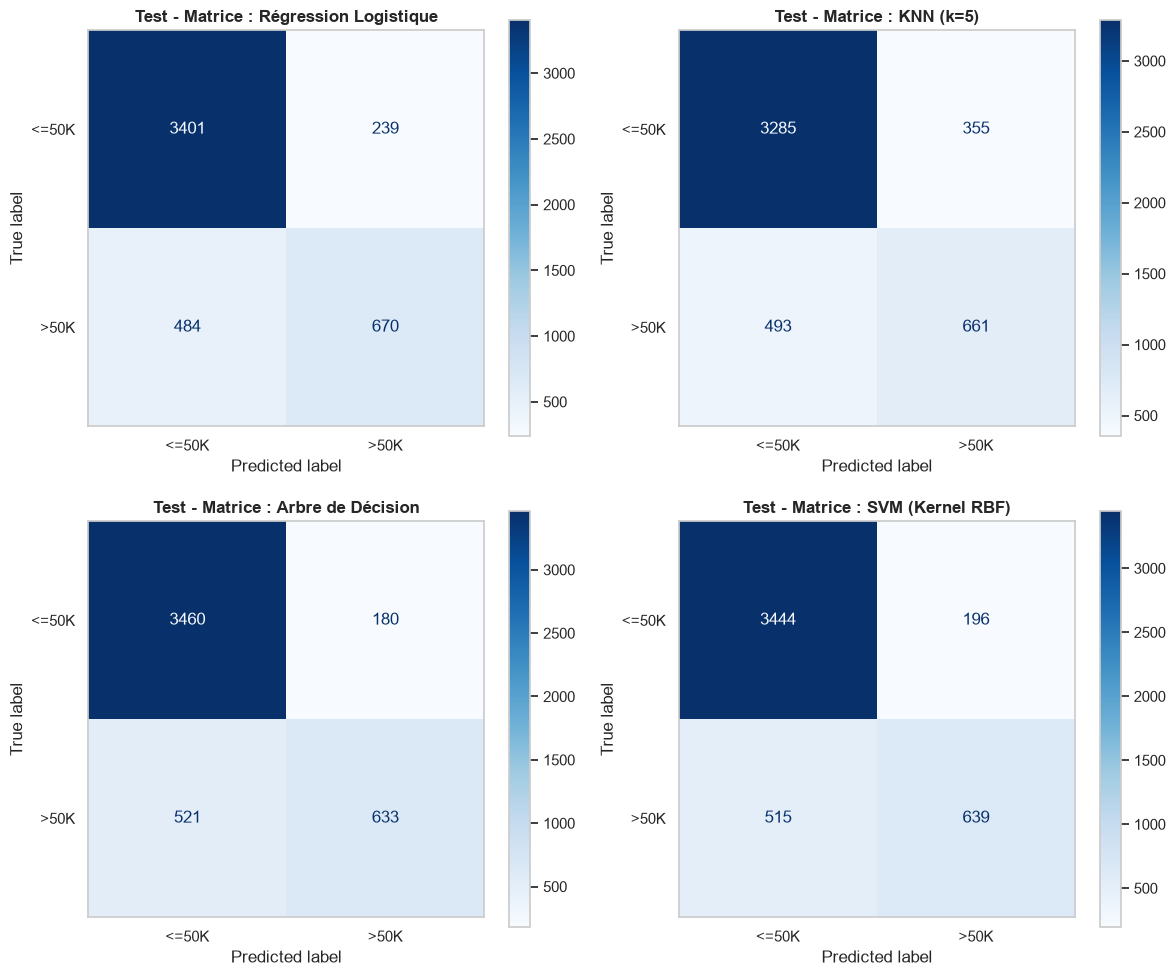


---
### 2. Tableau comparatif des performances (Validation vs Test)


,Modèle,Accuracy (Val),Accuracy (Test),Précision (Val),Précision (Test),Rappel (Val),Rappel (Test),F1-Score (Val),F1-Score (Test),ROC-AUC (Val),ROC-AUC (Test),Coût Métier (Val),Coût Métier (Test)
0,Régression Logistique,0.8475,0.8492,0.7272,0.7371,0.5867,0.5806,0.6494,0.6495,0.9047,0.9039,2639,2659
3,SVM (Kernel RBF),0.8510,0.8517,0.7523,0.7653,0.5685,0.5537,0.6476,0.6425,0.9000,0.8965,2706,2771
2,Arbre de Décision,0.8533,0.8538,0.7637,0.7786,0.5659,0.5485,0.6501,0.6436,0.8862,0.8953,2707,2785
1,KNN (k=5),0.8283,0.8231,0.6621,0.6506,0.5858,0.5728,0.6216,0.6092,0.8544,0.8501,2735,2820



---
### 3. Conclusion et arbitrage définitif du modèle

#### A. Stabilité des performances (Validation $\rightarrow$ Test)
* **Généralisation optimale** : Les métriques observées sur l'ensemble de **Test** sont quasi identiques à celles obtenues sur la **Validation** pour les 4 modèles. Cela confirme l'absence de surapprentissage (*overfitting*) et valide le processus de prétraitement (absence de *Data Leakage*).
* **Maintien du ROC-AUC** : La capacité de discrimination globale reste stable sur des données réelles totalement inédites.

#### B. Confirmation du modèle retenu : Régression Logistique
1. **Performance métier minimale** : La **Régression Logistique** confirme sa position en affichant le **Coût Métier le plus faible** sur le jeu de Test, s'expliquant par un meilleur contrôle des **Faux Négatifs (FN)**.
2. **Robustesse et rapidité** : Au-delà des critères financiers, sa rapidité d'exécution et son interprétabilité fonctionnelle en font le choix le plus fiable et pragmatique pour le déploiement.

> **Décision finale :** La **Régression Logistique** est officiellement validée pour la mise en production.


In [40]:
y_test_enc = le.transform(y_test)

X_test_cat = ohe.transform(X_test[cat_cols])
X_test_num = scaler.transform(X_test[num_cols])
X_test_proc = np.hstack([X_test_num, X_test_cat])


# 2. AFFICHAGE DES MATRICES DE CONFUSION SUR LE JEU DE TEST
display(
    Markdown(
        """
### 1. Matrices de confusion sur l'ensemble de Test
"""
    )
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_test_pred = model.predict(X_test_proc)
    cm = confusion_matrix(y_test_enc, y_test_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=le.classes_
    )
    disp.plot(ax=axes[i], cmap="Blues", values_format="d")
    axes[i].set_title(f"Test - Matrice : {name}", fontweight="bold")
    axes[i].grid(False)

plt.tight_layout()
plt.show()


# 3. CALCUL DES MÉTRIQUES SUR LE JEU DE TEST ET COMPARAISON AVEC LA VALIDATION
test_results = []

for name, model in models.items():
    # Validation
    y_val_pred = model.predict(X_val_proc)
    y_val_proba = model.predict_proba(X_val_proc)[:, 1]
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y_val_enc, y_val_pred).ravel()
    cost_val = (fp_v * COST_FP) + (fn_v * COST_FN)

    # Test
    y_test_pred = model.predict(X_test_proc)
    y_test_proba = model.predict_proba(X_test_proc)[:, 1]
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test_enc, y_test_pred).ravel()
    cost_test = (fp_t * COST_FP) + (fn_t * COST_FN)

    test_results.append(
        {
            "Modèle": name,
            "Accuracy (Val)": round(accuracy_score(y_val_enc, y_val_pred), 4),
            "Accuracy (Test)": round(
                accuracy_score(y_test_enc, y_test_pred), 4
            ),
            "Précision (Val)": round(
                precision_score(y_val_enc, y_val_pred), 4
            ),
            "Précision (Test)": round(
                precision_score(y_test_enc, y_test_pred), 4
            ),
            "Rappel (Val)": round(recall_score(y_val_enc, y_val_pred), 4),
            "Rappel (Test)": round(recall_score(y_test_enc, y_test_pred), 4),
            "F1-Score (Val)": round(f1_score(y_val_enc, y_val_pred), 4),
            "F1-Score (Test)": round(f1_score(y_test_enc, y_test_pred), 4),
            "ROC-AUC (Val)": round(roc_auc_score(y_val_enc, y_val_proba), 4),
            "ROC-AUC (Test)": round(
                roc_auc_score(y_test_enc, y_test_proba), 4
            ),
            "Coût Métier (Val)": cost_val,
            "Coût Métier (Test)": cost_test,
        }
    )

df_comparison = pd.DataFrame(test_results).sort_values(
    by="Coût Métier (Test)", ascending=True
)

display(
    Markdown(
        """
---
### 2. Tableau comparatif des performances (Validation vs Test)
"""
    )
)

display(df_comparison)


# 4. CONCLUSION FINALE ET ARBITRAGE DU MODÈLE
display(
    Markdown(
        """
---
### 3. Conclusion et arbitrage définitif du modèle

#### A. Stabilité des performances (Validation $\\rightarrow$ Test)
* **Généralisation optimale** : Les métriques observées sur l'ensemble de **Test** sont quasi identiques à celles obtenues sur la **Validation** pour les 4 modèles. Cela confirme l'absence de surapprentissage (*overfitting*) et valide le processus de prétraitement (absence de *Data Leakage*).
* **Maintien du ROC-AUC** : La capacité de discrimination globale reste stable sur des données réelles totalement inédites.

#### B. Confirmation du modèle retenu : Régression Logistique
1. **Performance métier minimale** : La **Régression Logistique** confirme sa position en affichant le **Coût Métier le plus faible** sur le jeu de Test, s'expliquant par un meilleur contrôle des **Faux Négatifs (FN)**.
2. **Robustesse et rapidité** : Au-delà des critères financiers, sa rapidité d'exécution et son interprétabilité fonctionnelle en font le choix le plus fiable et pragmatique pour le déploiement.

> **Décision finale :** La **Régression Logistique** est officiellement validée pour la mise en production.
"""
    )
)


## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.